# Discrete Metropolis-Hastings Algorithm: Knapsack Problem

This notebook demonstrates the Metropolis-Hastings algorithm for solving the 0/1 knapsack problem, a classic combinatorial optimization problem.

## Problem Description:
Given a set of items, each with a weight and a value, determine which items to include in a collection so that the total weight is less than or equal to a given limit and the total value is maximized.

## Key Features:
- Discrete state space (binary decisions for each item)
- Constraint optimization (weight limit)
- Non-physical application of Metropolis-Hastings

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time
from itertools import combinations

# Set up plotting parameters
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 14

## 1. Knapsack Problem Setup

We'll define a knapsack problem with a set of items, each with a weight and value.

In [2]:
class KnapsackProblem:
    def __init__(self, weights, values, capacity):
        """
        Initialize knapsack problem
        
        Parameters:
        - weights: list of item weights
        - values: list of item values
        - capacity: maximum weight capacity
        """
        self.weights = np.array(weights)
        self.values = np.array(values)
        self.capacity = capacity
        self.n_items = len(weights)
        
    def evaluate_solution(self, solution):
        """
        Evaluate a solution (binary vector)
        Returns: (total_value, total_weight, is_valid)
        """
        total_weight = np.sum(solution * self.weights)
        total_value = np.sum(solution * self.values)
        is_valid = total_weight <= self.capacity
        return total_value, total_weight, is_valid
    
    def generate_random_solution(self):
        """Generate a random valid solution"""
        while True:
            solution = np.random.randint(0, 2, self.n_items)
            _, _, is_valid = self.evaluate_solution(solution)
            if is_valid:
                return solution
    
    def get_best_solution_brute_force(self):
        """Find optimal solution using brute force (for small problems)"""
        best_value = 0
        best_solution = None
        
        for r in range(self.n_items + 1):
            for combo in combinations(range(self.n_items), r):
                solution = np.zeros(self.n_items)
                solution[list(combo)] = 1
                value, weight, is_valid = self.evaluate_solution(solution)
                if is_valid and value > best_value:
                    best_value = value
                    best_solution = solution.copy()
        
        return best_solution, best_value

# Create a knapsack problem instance
np.random.seed(42)
n_items = 15
weights = np.random.randint(1, 20, n_items)
values = np.random.randint(10, 100, n_items)
capacity = int(np.sum(weights) * 0.4)  # 40% of total weight capacity

knapsack = KnapsackProblem(weights, values, capacity)

print(f"Number of items: {n_items}")
print(f"Knapsack capacity: {capacity}")
print(f"Total weight of all items: {np.sum(weights)}")
print("\nItem details:")
print("Item\tWeight\tValue\tValue/Weight")
for i in range(n_items):
    print(f"{i+1}\t{weights[i]}\t{values[i]}\t{values[i]/weights[i]:.2f}")

Number of items: 15
Knapsack capacity: 50
Total weight of all items: 126

Item details:
Item	Weight	Value	Value/Weight
1	7	73	10.43
2	15	69	4.60
3	11	30	2.73
4	8	42	5.25
5	7	85	12.14
6	19	67	3.53
7	11	31	2.82
8	11	98	8.91
9	4	58	14.50
10	8	68	8.50
11	3	51	17.00
12	2	69	34.50
13	12	89	7.42
14	6	24	4.00
15	2	71	35.50


## 2. Target Distribution for Knapsack Problem

We'll define a target distribution that favors high-value solutions while respecting the weight constraint.

In [3]:
def target_distribution_knapsack(solution, knapsack, temperature=1.0, penalty_factor=10.0):
    """
    Target distribution for knapsack problem
    
    Parameters:
    - solution: binary vector representing item selection
    - knapsack: KnapsackProblem instance
    - temperature: controls exploration vs exploitation
    - penalty_factor: penalty for exceeding capacity
    """
    value, weight, is_valid = knapsack.evaluate_solution(solution)
    
    if is_valid:
        # Valid solution: use value as fitness
        fitness = value
    else:
        # Invalid solution: apply penalty for exceeding capacity
        excess = weight - knapsack.capacity
        fitness = value - penalty_factor * excess
    
    # Convert to probability using Boltzmann distribution
    return np.exp(fitness / temperature)

# Test the target distribution with some random solutions
print("Testing target distribution:")
for i in range(5):
    solution = np.random.randint(0, 2, n_items)
    value, weight, is_valid = knapsack.evaluate_solution(solution)
    prob = target_distribution_knapsack(solution, knapsack)
    print(f"Solution {i+1}: {solution}")
    print(f"  Value: {value}, Weight: {weight}, Valid: {is_valid}")
    print(f"  Probability: {prob:.6f}\n")

Testing target distribution:
Solution 1: [1 0 1 0 1 0 1 1 0 0 0 0 0 0 0]
  Value: 317, Weight: 47, Valid: True
  Probability: 469192178043501174785638326585413531246947123384424663983118930699256203302534264167566738508980872022109402691998918543623271503204712448.000000

Solution 2: [0 1 1 0 1 1 1 1 0 1 0 1 1 1 0]
  Value: 630, Weight: 102, Valid: False
  Probability: 592097202766466993617016430120581649425527472128.000000

Solution 3: [1 0 1 0 1 0 0 1 0 1 1 1 1 1 1]
  Value: 658, Weight: 69, Valid: False
  Probability: 177753242103085899147682267033770341813035121203239438342776821949121735637207797272174371557961455290558992583532838515346167521812102723733578195997990401064852672206677259332372367450892641736350236672.000000

Solution 4: [1 1 1 1 1 0 0 1 1 1 1 1 1 1 1]
  Value: 827, Weight: 96, Valid: False
  Probability: 2432623279471950387498655073109680002093092775825225804550192078322528275168955191528479352750193480716078702832548812379299710622896283958759272629350380339200.0

## 3. Proposal Distribution for Knapsack Problem

We'll use different types of moves to propose new solutions.

In [4]:
def propose_new_solution_knapsack(current_solution, move_type='random'):
    """
    Propose a new solution for knapsack problem
    
    Parameters:
    - current_solution: current binary solution
    - move_type: 'random', 'flip', 'swap', or 'add_remove'
    """
    new_solution = current_solution.copy()
    n_items = len(current_solution)
    
    if move_type == 'random':
        # Randomly choose a move type
        move_types = ['flip', 'swap', 'add_remove']
        move_type = np.random.choice(move_types)
    
    if move_type == 'flip':
        # Flip a random bit
        idx = np.random.randint(0, n_items)
        new_solution[idx] = 1 - new_solution[idx]
    
    elif move_type == 'swap':
        # Swap one selected item with one unselected item
        selected = np.where(current_solution == 1)[0]
        unselected = np.where(current_solution == 0)[0]
        
        if len(selected) > 0 and len(unselected) > 0:
            sel_idx = np.random.choice(selected)
            unsel_idx = np.random.choice(unselected)
            new_solution[sel_idx] = 0
            new_solution[unsel_idx] = 1
    
    elif move_type == 'add_remove':
        # Add an item or remove an item
        if np.random.random() < 0.5:
            # Add an item
            unselected = np.where(current_solution == 0)[0]
            if len(unselected) > 0:
                idx = np.random.choice(unselected)
                new_solution[idx] = 1
        else:
            # Remove an item
            selected = np.where(current_solution == 1)[0]
            if len(selected) > 0:
                idx = np.random.choice(selected)
                new_solution[idx] = 0
    
    return new_solution

# Test the proposal distribution
print("Testing proposal distribution:")
initial_solution = np.random.randint(0, 2, n_items)
print(f"Initial solution: {initial_solution}")

for move_type in ['flip', 'swap', 'add_remove']:
    new_solution = propose_new_solution_knapsack(initial_solution, move_type)
    print(f"{move_type} move: {new_solution}")
    print(f"  Changed positions: {np.where(initial_solution != new_solution)[0]}")

Testing proposal distribution:
Initial solution: [0 1 1 0 1 1 1 0 0 0 0 0 0 0 0]
flip move: [0 1 1 0 1 1 1 0 1 0 0 0 0 0 0]
  Changed positions: [8]
swap move: [0 0 1 0 1 1 1 0 0 0 0 0 1 0 0]
  Changed positions: [ 1 12]
add_remove move: [0 1 1 0 1 1 1 1 0 0 0 0 0 0 0]
  Changed positions: [7]


## 4. Discrete Metropolis-Hastings Algorithm for Knapsack

Now we implement the Metropolis-Hastings algorithm for the knapsack problem.

In [5]:
def metropolis_hastings_knapsack(knapsack, initial_solution, target_func, proposal_func,
                                num_samples, temperature=1.0, move_type='random'):
    """
    Metropolis-Hastings algorithm for knapsack problem
    
    Parameters:
    - knapsack: KnapsackProblem instance
    - initial_solution: starting binary solution
    - target_func: target distribution function
    - proposal_func: proposal distribution function
    - num_samples: number of iterations
    - temperature: temperature parameter
    - move_type: type of move for proposal
    """
    samples = []
    values = []
    weights = []
    validities = []
    
    current_solution = initial_solution.copy()
    accepted = 0
    
    for i in range(num_samples):
        # Propose new solution
        proposed_solution = proposal_func(current_solution, move_type)
        
        # Calculate acceptance probability
        current_prob = target_func(current_solution, knapsack, temperature)
        proposed_prob = target_func(proposed_solution, knapsack, temperature)
        
        acceptance_prob = min(1, proposed_prob / current_prob)
        
        # Accept or reject
        if np.random.random() < acceptance_prob:
            current_solution = proposed_solution
            accepted += 1
        
        # Store current solution and its properties
        value, weight, is_valid = knapsack.evaluate_solution(current_solution)
        samples.append(current_solution.copy())
        values.append(value)
        weights.append(weight)
        validities.append(is_valid)
    
    acceptance_rate = accepted / num_samples
    return samples, values, weights, validities, acceptance_rate

# Run the algorithm
np.random.seed(42)
num_samples = 5000
initial_solution = knapsack.generate_random_solution()
temperature = 10.0
move_type = 'random'

samples, values, weights, validities, acceptance_rate = metropolis_hastings_knapsack(
    knapsack, initial_solution, target_distribution_knapsack, 
    propose_new_solution_knapsack, num_samples, temperature, move_type
)

print(f"Acceptance rate: {acceptance_rate:.2%}")
print(f"Number of samples: {len(samples)}")
print(f"Initial solution value: {values[0]}, weight: {weights[0]}")
print(f"Best solution found: value = {max(values)}, weight = {weights[np.argmax(values)]}")

Acceptance rate: 7.60%
Number of samples: 5000
Initial solution value: 317, weight: 52
Best solution found: value = 729, weight = 75


## 5. Analyzing the Results

In [6]:
# Find best solution
best_idx = np.argmax(values)
best_solution = samples[best_idx]
best_value = values[best_idx]
best_weight = weights[best_idx]
best_valid = validities[best_idx]

print("Best solution found:")
print(f"Solution: {best_solution}")
print(f"Selected items: {np.where(best_solution == 1)[0] + 1}")
print(f"Total value: {best_value}")
print(f"Total weight: {best_weight}")
print(f"Is valid: {best_valid}")
print(f"Capacity: {knapsack.capacity}")

# Compare with brute force solution (if problem size is manageable)
if knapsack.n_items <= 20:
    optimal_solution, optimal_value = knapsack.get_best_solution_brute_force()
    print(f"\nOptimal solution (brute force):")
    print(f"Solution: {optimal_solution}")
    print(f"Selected items: {np.where(optimal_solution == 1)[0] + 1}")
    print(f"Optimal value: {optimal_value}")
    print(f"Gap to optimal: {optimal_value - best_value}")

Best solution found:
Solution: [1 0 0 0 1 1 0 1 1 1 1 1 1 0 1]
Selected items: [ 1  5  6  8  9 10 11 12 13 15]
Total value: 729
Total weight: 75
Is valid: False
Capacity: 50

Optimal solution (brute force):
Solution: [1. 0. 0. 0. 1. 0. 0. 1. 1. 1. 1. 1. 0. 1. 1.]
Selected items: [ 1  5  8  9 10 11 12 14 15]
Optimal value: 597.0
Gap to optimal: -132.0


## 6. Visualization of Results

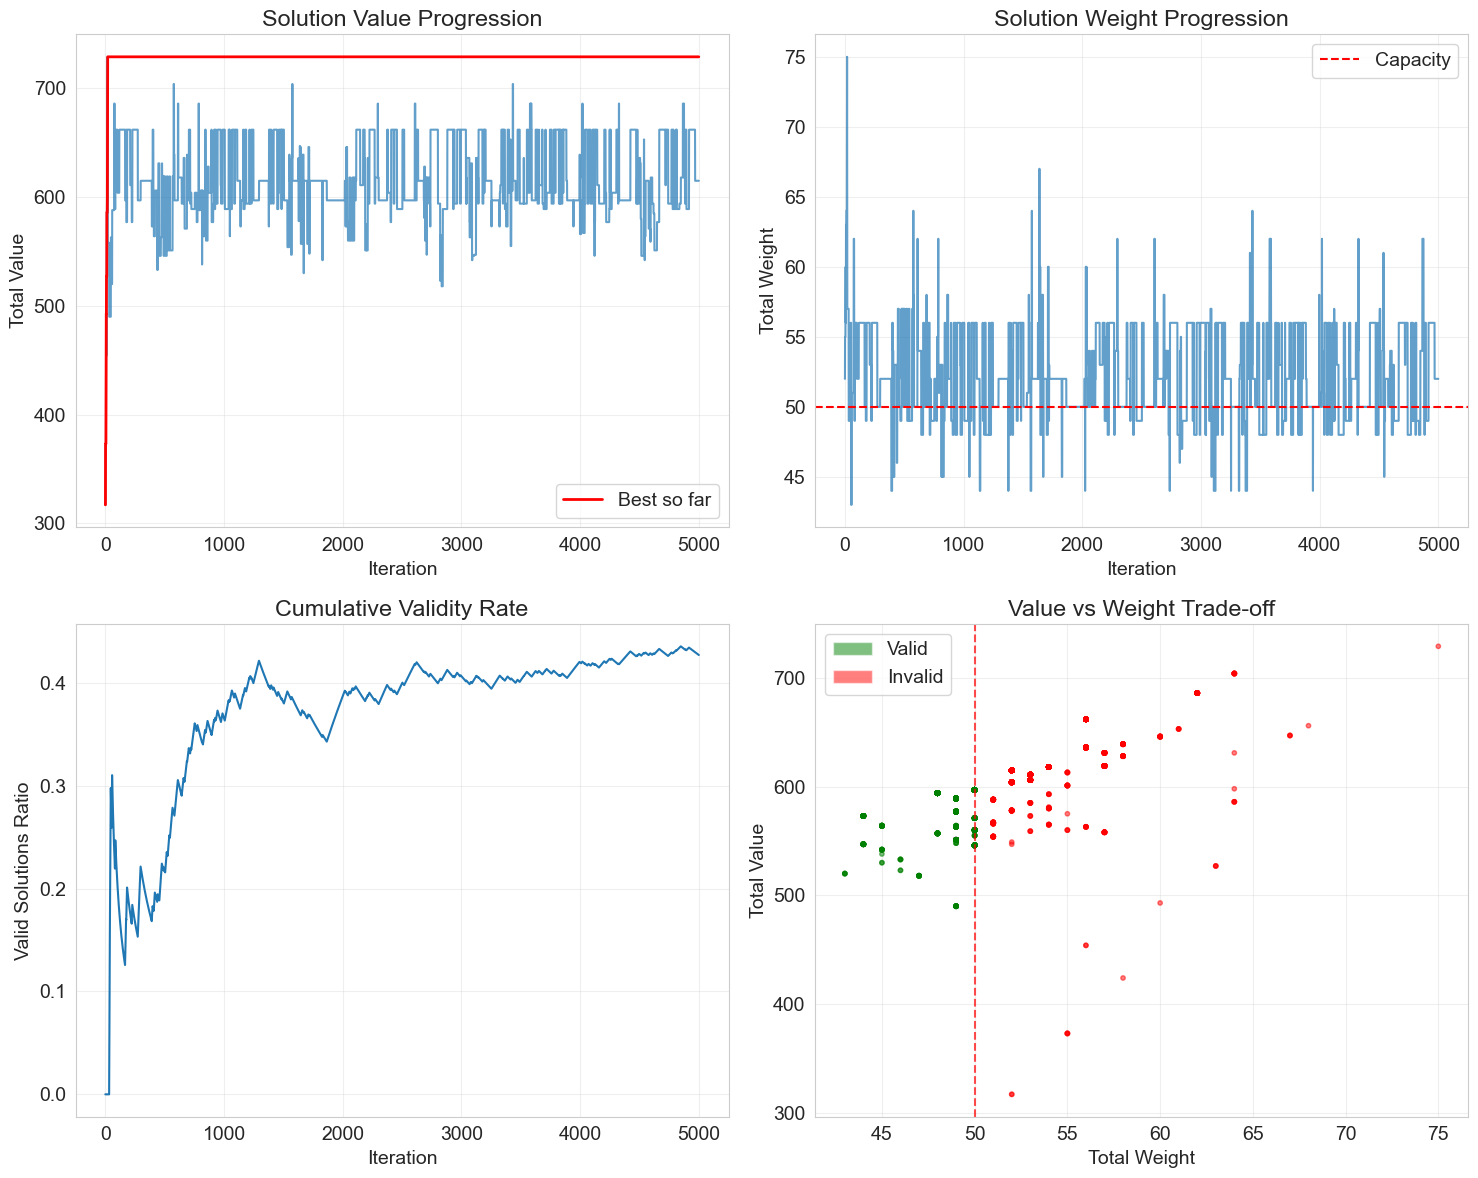

In [7]:
# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Value progression
axes[0, 0].plot(values, alpha=0.7)
axes[0, 0].plot(np.maximum.accumulate(values), 'r-', linewidth=2, label='Best so far')
axes[0, 0].set_title('Solution Value Progression')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Total Value')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Weight progression
axes[0, 1].plot(weights, alpha=0.7)
axes[0, 1].axhline(y=knapsack.capacity, color='r', linestyle='--', label='Capacity')
axes[0, 1].set_title('Solution Weight Progression')
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Total Weight')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Validity histogram
valid_counts = [sum(validities[:i+1]) / (i+1) for i in range(len(validities))]
axes[1, 0].plot(valid_counts)
axes[1, 0].set_title('Cumulative Validity Rate')
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_ylabel('Valid Solutions Ratio')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Value vs Weight scatter
colors = ['green' if v else 'red' for v in validities]
scatter = axes[1, 1].scatter(weights, values, c=colors, alpha=0.5, s=10)
axes[1, 1].axvline(x=knapsack.capacity, color='r', linestyle='--', alpha=0.7)
axes[1, 1].set_title('Value vs Weight Trade-off')
axes[1, 1].set_xlabel('Total Weight')
axes[1, 1].set_ylabel('Total Value')
axes[1, 1].grid(True, alpha=0.3)

# Add legend for validity
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', alpha=0.5, label='Valid'),
                    Patch(facecolor='red', alpha=0.5, label='Invalid')]
axes[1, 1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

## 7. Effect of Temperature on Performance

Temperature controls the exploration vs exploitation trade-off.

/var/folders/8x/k_m4pmb11437ktb_r6tjzt2c0000gn/T/ipykernel_71076/101966350.py:22: RuntimeWarning: overflow encountered in exp
  return np.exp(fitness / temperature)
/var/folders/8x/k_m4pmb11437ktb_r6tjzt2c0000gn/T/ipykernel_71076/437453192.py:31: RuntimeWarning: invalid value encountered in scalar divide
  acceptance_prob = min(1, proposed_prob / current_prob)


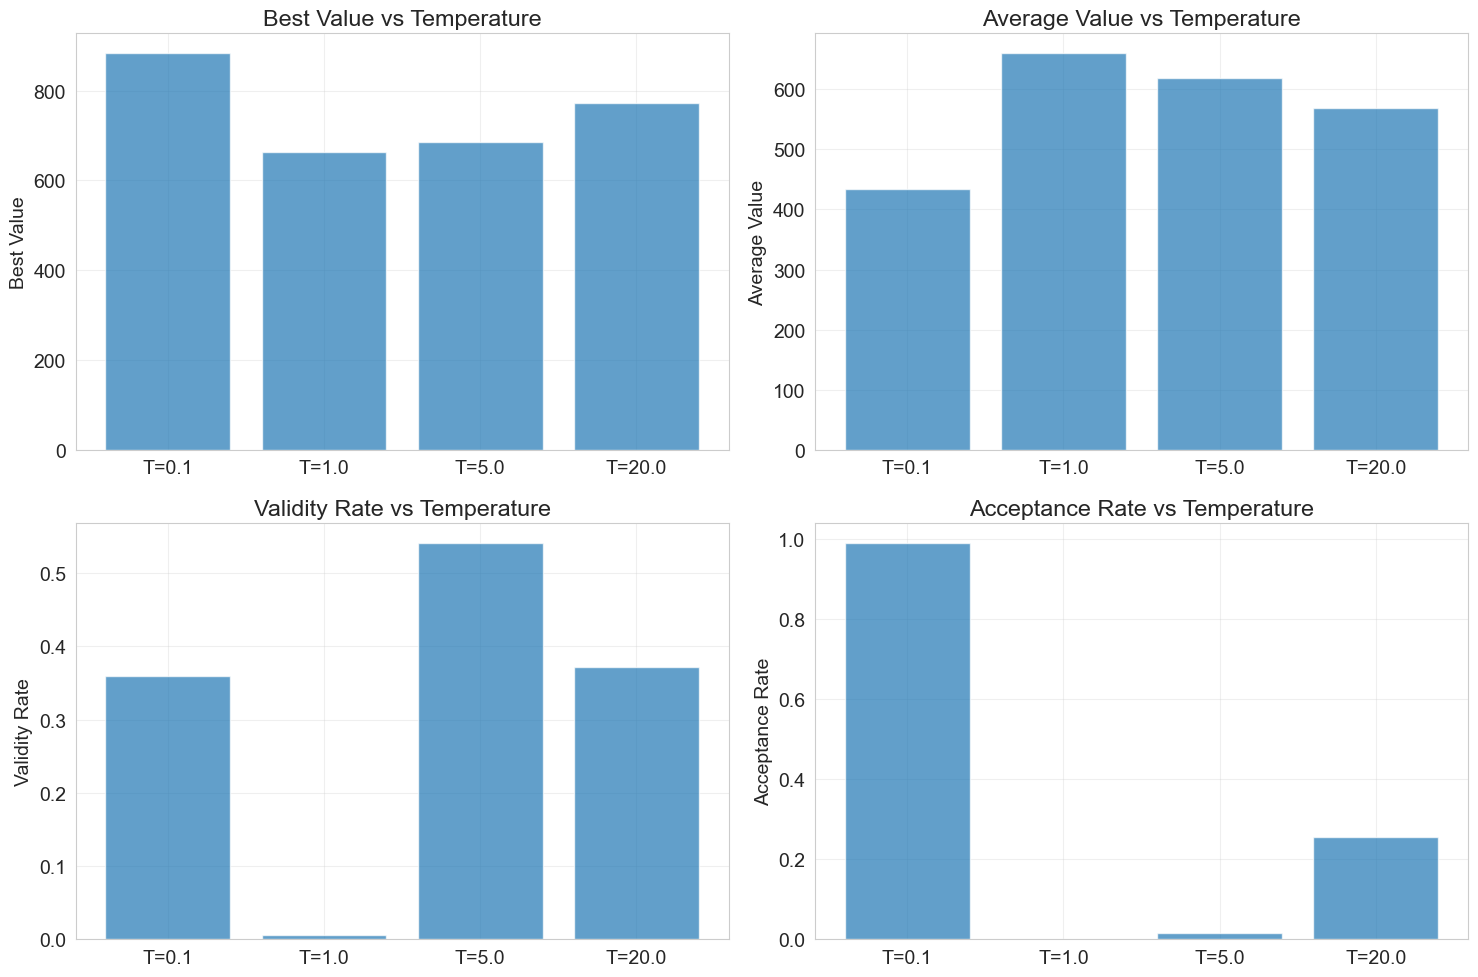

Performance at Different Temperatures:
--------------------------------------------------------------------------------
Temperature  Best Value   Avg Value    Validity Rate  Acceptance Rate 
--------------------------------------------------------------------------------
0.1          883          434.50       35.88%         99.08%          
1.0          662          659.91       0.52%          0.18%           
5.0          686          618.89       54.14%         1.54%           
20.0         773          568.30       37.18%         25.66%          


In [8]:
# Test different temperatures
temperatures = [0.1, 1.0, 5.0, 20.0]
results_temp = {}

for temp in temperatures:
    samples_temp, values_temp, weights_temp, validities_temp, acceptance_rate_temp = metropolis_hastings_knapsack(
        knapsack, initial_solution, target_distribution_knapsack, 
        propose_new_solution_knapsack, num_samples, temp, move_type
    )
    
    best_value_temp = max(values_temp)
    best_weight_temp = weights_temp[np.argmax(values_temp)]
    avg_value_temp = np.mean(values_temp)
    validity_rate_temp = sum(validities_temp) / len(validities_temp)
    
    results_temp[temp] = {
        'best_value': best_value_temp,
        'best_weight': best_weight_temp,
        'avg_value': avg_value_temp,
        'validity_rate': validity_rate_temp,
        'acceptance_rate': acceptance_rate_temp
    }

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

metrics = ['best_value', 'avg_value', 'validity_rate', 'acceptance_rate']
titles = ['Best Value', 'Average Value', 'Validity Rate', 'Acceptance Rate']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    values = [results_temp[temp][metric] for temp in temperatures]
    axes[i].bar(range(len(temperatures)), values, alpha=0.7)
    axes[i].set_xticks(range(len(temperatures)))
    axes[i].set_xticklabels([f'T={temp}' for temp in temperatures])
    axes[i].set_title(f'{title} vs Temperature')
    axes[i].set_ylabel(title)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed results
print("Performance at Different Temperatures:")
print("-" * 80)
print(f"{'Temperature':<12} {'Best Value':<12} {'Avg Value':<12} {'Validity Rate':<14} {'Acceptance Rate':<16}")
print("-" * 80)
for temp in temperatures:
    result = results_temp[temp]
    print(f"{temp:<12} {result['best_value']:<12} {result['avg_value']:<12.2f} "
          f"{result['validity_rate']:<14.2%} {result['acceptance_rate']:<16.2%}")

## 8. Comparison of Different Move Types

Let's compare the performance of different proposal strategies.

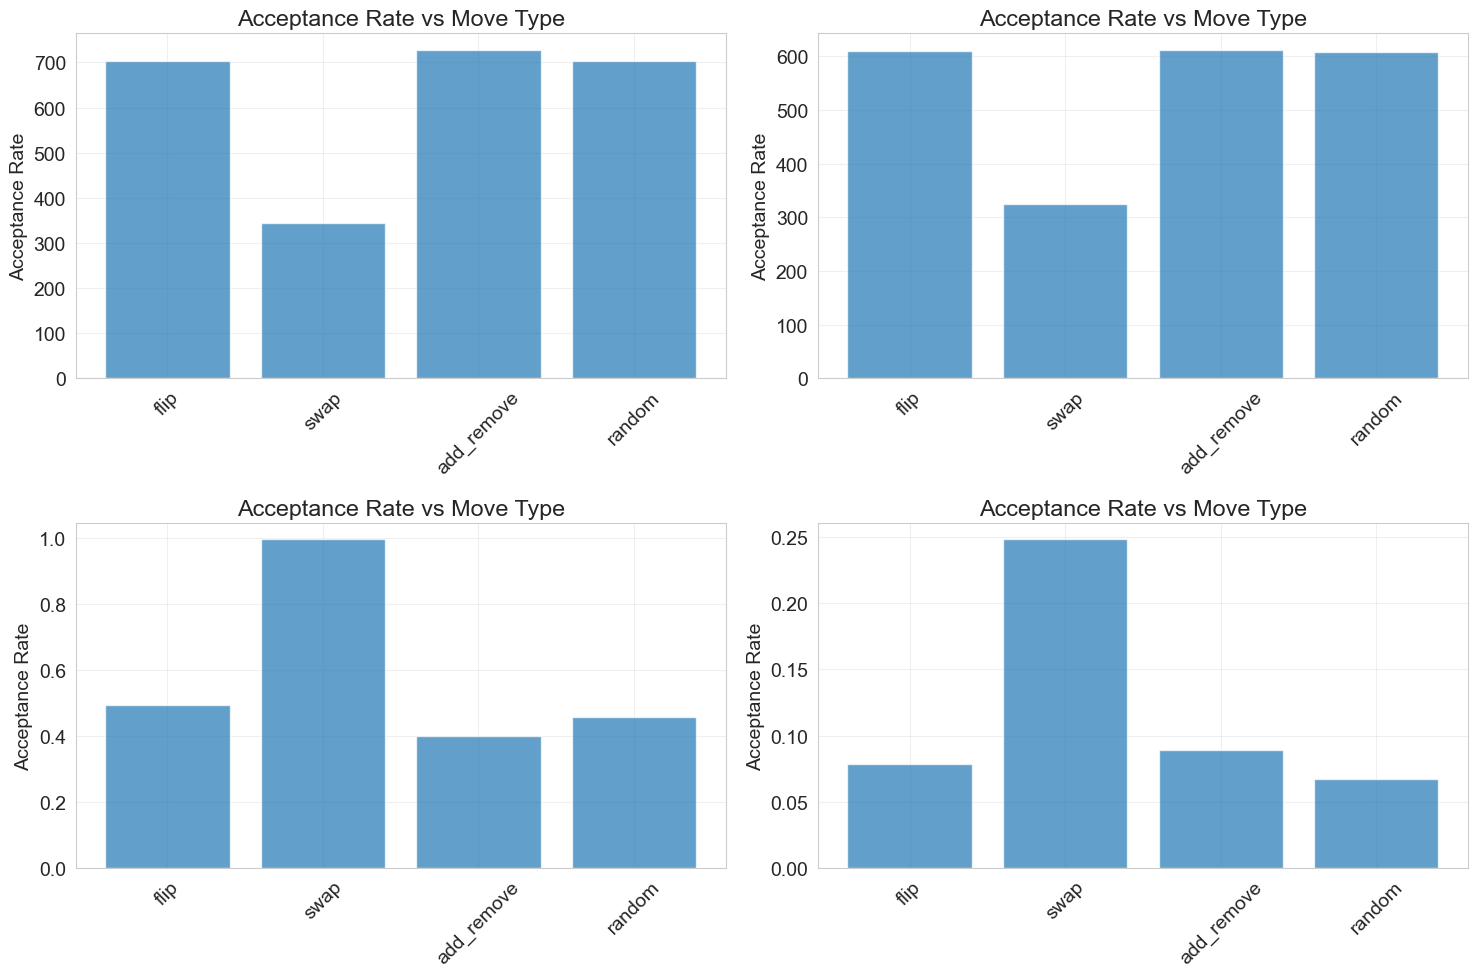

Performance of Different Move Types:
--------------------------------------------------------------------------------
Move Type    Best Value   Avg Value    Validity Rate  Acceptance Rate 
--------------------------------------------------------------------------------
flip         704          609.83       49.56%         7.84%           
swap         345          324.76       99.74%         24.84%          
add_remove   728          612.25       40.12%         8.92%           
random       704          608.26       45.80%         6.70%           


In [9]:
# Test different move types
move_types = ['flip', 'swap', 'add_remove', 'random']
results_moves = {}

for move in move_types:
    samples_move, values_move, weights_move, validities_move, acceptance_rate_move = metropolis_hastings_knapsack(
        knapsack, initial_solution, target_distribution_knapsack, 
        propose_new_solution_knapsack, num_samples, temperature, move
    )
    
    best_value_move = max(values_move)
    avg_value_move = np.mean(values_move)
    validity_rate_move = sum(validities_move) / len(validities_move)
    
    results_moves[move] = {
        'best_value': best_value_move,
        'avg_value': avg_value_move,
        'validity_rate': validity_rate_move,
        'acceptance_rate': acceptance_rate_move
    }

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    values = [results_moves[move][metric] for move in move_types]
    axes[i].bar(move_types, values, alpha=0.7)
    axes[i].set_title(f'{title} vs Move Type')
    axes[i].set_ylabel(title)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed results
print("Performance of Different Move Types:")
print("-" * 80)
print(f"{'Move Type':<12} {'Best Value':<12} {'Avg Value':<12} {'Validity Rate':<14} {'Acceptance Rate':<16}")
print("-" * 80)
for move in move_types:
    result = results_moves[move]
    print(f"{move:<12} {result['best_value']:<12} {result['avg_value']:<12.2f} "
          f"{result['validity_rate']:<14.2%} {result['acceptance_rate']:<16.2%}")

## 9. Key Takeaways

### Discrete Metropolis-Hastings for Optimization:

1. **State Representation**: Binary vectors for discrete decisions
2. **Target Distribution**: Encodes optimization objective with constraints
3. **Proposal Mechanisms**: Different move strategies for exploration
4. **Temperature Control**: Balances exploration vs exploitation

### Advantages:
- Can handle complex constraints through penalty functions
- Flexible proposal mechanisms for different problem structures
- Provides probabilistic framework for deterministic optimization
- Can escape local optima through controlled random exploration

### Applications:
- Combinatorial optimization (knapsack, traveling salesman, etc.)
- Feature selection in machine learning
- Resource allocation problems
- Scheduling and planning